# AgentX / CC-Traces Benchmark Visualization Playground

This interactive notebook analyzes and visualizes results from the **Moonshot Kimi-K3 AgentX (CC-Traces)** benchmark runs.

### Key Artifacts Loaded:
1. `profile_export_aiperf.json`: AIPerf summary metrics (throughput, TTFT, ITL, total token sums).
2. `trace-cost-breakdown.json`: Per-trace token aggregation, KV cache hit rate, and dollar spend.
3. `profile_export.jsonl` / `profile_export_raw.jsonl`: Turn-by-turn request records with granular latencies and token counts.

---

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 1. Plotting Configuration & Aesthetics
# ---------------------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
})

# ---------------------------------------------------------------------------
# 2. Artifact Directory & File Paths
# ---------------------------------------------------------------------------
RUN_ROOT = Path("/data/semi-analysis-report/results/kimi-k3-agentx-20260904T121154Z-070ffb74")

PROVIDER_ARTIFACTS = {
    "baseten": RUN_ROOT / "models/kimi-k3/providers/baseten/performance/agentx-c1/performance--kimi-k3--baseten--agentx--c1--7014ad06/artifacts",
    "fireworks": RUN_ROOT / "models/kimi-k3/providers/fireworks/performance/agentx-c1/performance--kimi-k3--fireworks--agentx--c1--6441f039/artifacts",
    "together": RUN_ROOT / "models/kimi-k3/providers/together/performance/agentx-c1/performance--kimi-k3--together--agentx--c1--a2e78e3a/artifacts",
}

# Select primary provider for in-depth trace analysis ('baseten', 'fireworks', 'together')
SELECTED_PROVIDER = "baseten"
ARTIFACTS_DIR = PROVIDER_ARTIFACTS[SELECTED_PROVIDER]

PROFILE_AIPERF_PATH = ARTIFACTS_DIR / "profile_export_aiperf.json"
TRACE_COST_PATH = ARTIFACTS_DIR / "trace-cost-breakdown.json"
PROFILE_EXPORT_PATH = ARTIFACTS_DIR / "profile_export.jsonl"
RAW_EXPORT_PATH = ARTIFACTS_DIR / "profile_export_raw.jsonl"

print(f"Selected Provider: {SELECTED_PROVIDER.upper()}")
print(f"Artifacts Dir:    {ARTIFACTS_DIR}")
print(f"  • profile_export_aiperf.json: {PROFILE_AIPERF_PATH.exists()}")
print(f"  • trace-cost-breakdown.json:  {TRACE_COST_PATH.exists()}")
print(f"  • profile_export.jsonl:       {PROFILE_EXPORT_PATH.exists()}")
print(f"  • profile_export_raw.jsonl:   {RAW_EXPORT_PATH.exists()}")


Selected Provider: BASETEN
Artifacts Dir:    /data/semi-analysis-report/results/kimi-k3-agentx-20260904T121154Z-070ffb74/models/kimi-k3/providers/baseten/performance/agentx-c1/performance--kimi-k3--baseten--agentx--c1--7014ad06/artifacts
  • profile_export_aiperf.json: True
  • trace-cost-breakdown.json:  True
  • profile_export.jsonl:       True
  • profile_export_raw.jsonl:   True


## 2. Ingest Artifacts & Build Turn-by-Turn DataFrame

We parse the summary, per-trace breakdown, and individual request records into structured DataFrames.

In [2]:
def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_jsonl(path: Path) -> list[dict]:
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

# Ingest summary and trace breakdown
aiperf_summary = load_json(PROFILE_AIPERF_PATH)
trace_breakdown = load_json(TRACE_COST_PATH)

# Ingest per-turn profiling records (fallback to raw if needed)
records_file = PROFILE_EXPORT_PATH if PROFILE_EXPORT_PATH.exists() else RAW_EXPORT_PATH
raw_records = load_jsonl(records_file)

# Extract pricing rates
rates = trace_breakdown.get("pricingRates", {})
prompt_rate = rates.get("inputUsdPerMillion") or 3.0
cached_rate = rates.get("cachedInputUsdPerMillion") or 0.30
comp_rate = rates.get("outputUsdPerMillion") or 15.0

turn_rows = []
for r in raw_records:
    meta = r.get("metadata", {})
    metrics = r.get("metrics", {})
    
    # Filter warmup records
    phase = str(meta.get("benchmark_phase") or meta.get("phase_kind") or "").lower()
    if phase and "warmup" in phase:
        continue
        
    trace_id = (
        meta.get("source_trace_id")
        or meta.get("conversation_id")
        or meta.get("session_id")
        or str(meta.get("session_num", "unknown"))
    )
    
    isl = metrics.get("input_sequence_length", {}).get("value", 0)
    cached_isl = metrics.get("usage_prompt_cache_read_tokens", {}).get("value", 0)
    uncached_isl = max(0, isl - cached_isl)
    osl = metrics.get("output_sequence_length", {}).get("value")
    if osl is None:
        osl = metrics.get("output_token_count", {}).get("value", 0)
    reasoning = metrics.get("reasoning_token_count", {}).get("value")
    if reasoning is None:
        reasoning = metrics.get("usage_reasoning_tokens", {}).get("value", 0)
        
    cost = (uncached_isl * prompt_rate / 1e6) + (cached_isl * cached_rate / 1e6) + (osl * comp_rate / 1e6)
    hit_rate = cached_isl / isl if isl > 0 else 0.0
    
    turn_rows.append({
        "session_num": meta.get("session_num", 0),
        "turn_index": meta.get("turn_index", 0),
        "source_trace_id": trace_id,
        "trace_short": trace_id[:8] + "...",
        "agent_depth": meta.get("agent_depth", 0),
        "input_tokens": int(isl),
        "cached_tokens": int(cached_isl),
        "uncached_tokens": int(uncached_isl),
        "output_tokens": int(osl),
        "reasoning_tokens": int(reasoning),
        "total_tokens": int(isl + osl),
        "cache_hit_rate": hit_rate,
        "cost_usd": cost,
        "latency_ms": metrics.get("request_latency", {}).get("value", 0.0),
        "ttft_ms": metrics.get("time_to_first_token", {}).get("value", 0.0),
        "waiting_ms": metrics.get("http_req_waiting", {}).get("value", 0.0),
        "decode_duration_ms": metrics.get("decode_duration", {}).get("value", 0.0),
        "itl_ms": metrics.get("inter_token_latency", {}).get("value", 0.0),
        "decode_throughput": metrics.get("output_token_throughput_per_user", {}).get("value", 0.0),
        "e2e_throughput": metrics.get("e2e_output_token_throughput", {}).get("value", 0.0),
    })

df_turns = pd.DataFrame(turn_rows)
df_traces = pd.DataFrame(trace_breakdown.get("traces", []))

print(f"Successfully parsed {len(df_turns)} turns across {len(df_traces)} traces.")
df_traces


Successfully parsed 73 turns across 3 traces.


,traceId,requestCount,inputTokens,cachedInputTokens,uncachedInputTokens,cacheWriteTokens,cacheHitRate,outputTokens,reasoningTokens,totalTokens,estimatedCostUsd,costPerRequestUsd
0,006c98de37d819e95b0840e25426bb7ca99d,28,2580246,2517868,62378,0,0.9758,15483,245,2595729,1.174739,0.041955
1,04dba6fe621301a1d01fd63b8d02c9645c48,25,724963,550116,174847,0,0.7588,40211,10315,765174,1.292741,0.051710
2,05f72f78a037cfa5cd4e4541960a574701d9,20,1212988,1071796,141192,0,0.8836,19402,1644,1232390,1.036145,0.051807


## 3. Complete Formatted Summary Table

Publication-ready visual table rendering both run-level overview and granular per-trace economics.

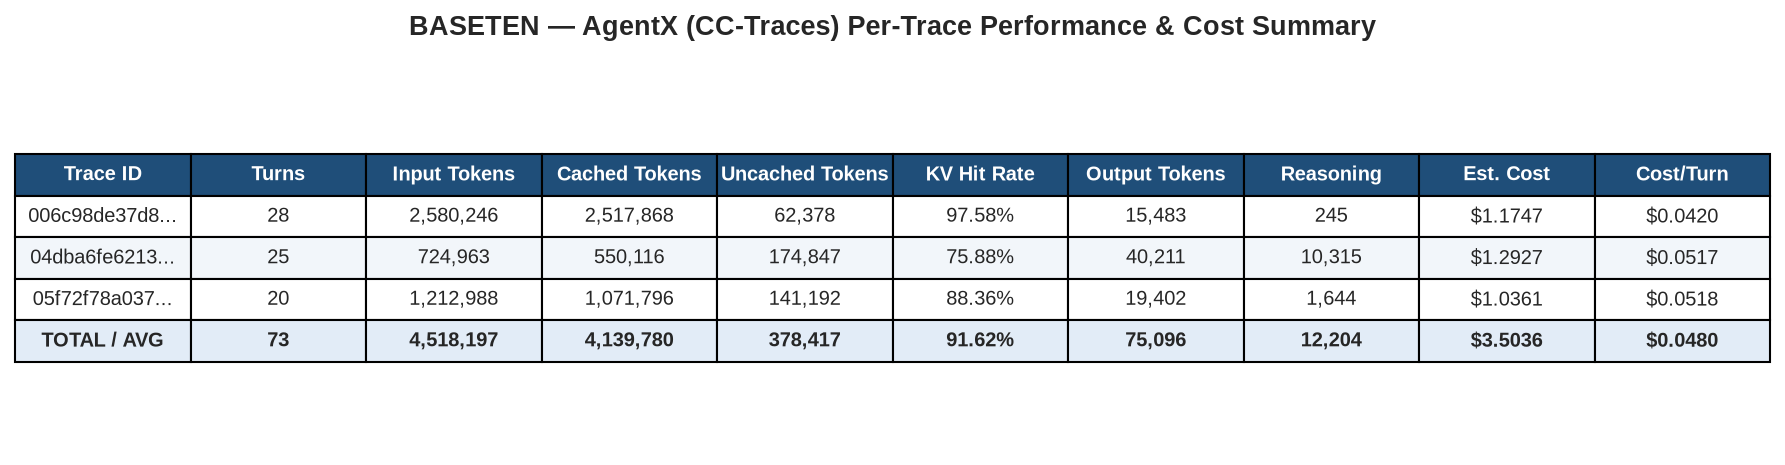

In [3]:
# Prepare formatted tabular data
table_rows = []
for t in trace_breakdown.get("traces", []):
    table_rows.append([
        t["traceId"][:12] + "...",
        f"{t['requestCount']}",
        f"{t['inputTokens']:,}",
        f"{t['cachedInputTokens']:,}",
        f"{t['uncachedInputTokens']:,}",
        f"{t['cacheHitRate'] * 100:.2f}%",
        f"{t['outputTokens']:,}",
        f"{t['reasoningTokens']:,}",
        f"${t['estimatedCostUsd']:.4f}",
        f"${t['costPerRequestUsd']:.4f}",
    ])

# Append summary total row
tot_reqs = trace_breakdown.get("totalRequests", 0)
tot_cost = trace_breakdown.get("totalEstimatedCostUsd", 0.0)
avg_cost = trace_breakdown.get("avgCostPerTraceUsd", 0.0)
tot_inp = sum(t["inputTokens"] for t in trace_breakdown.get("traces", []))
tot_cached = sum(t["cachedInputTokens"] for t in trace_breakdown.get("traces", []))
tot_uncached = sum(t["uncachedInputTokens"] for t in trace_breakdown.get("traces", []))
tot_out = sum(t["outputTokens"] for t in trace_breakdown.get("traces", []))
tot_reas = sum(t["reasoningTokens"] for t in trace_breakdown.get("traces", []))
overall_hit = tot_cached / tot_inp if tot_inp > 0 else 0.0

table_rows.append([
    "TOTAL / AVG",
    f"{tot_reqs}",
    f"{tot_inp:,}",
    f"{tot_cached:,}",
    f"{tot_uncached:,}",
    f"{overall_hit * 100:.2f}%",
    f"{tot_out:,}",
    f"{tot_reas:,}",
    f"${tot_cost:.4f}",
    f"${(tot_cost / tot_reqs) if tot_reqs else 0:.4f}",
])

col_labels = [
    "Trace ID",
    "Turns",
    "Input Tokens",
    "Cached Tokens",
    "Uncached Tokens",
    "KV Hit Rate",
    "Output Tokens",
    "Reasoning",
    "Est. Cost",
    "Cost/Turn",
]

# Create Matplotlib Figure for the Table
fig, ax = plt.subplots(figsize=(12, 3.2), dpi=150)
ax.axis('off')
ax.set_title(
    f"{SELECTED_PROVIDER.upper()} — AgentX (CC-Traces) Per-Trace Performance & Cost Summary",
    fontsize=13,
    fontweight='bold',
    pad=15
)

table = ax.table(
    cellText=table_rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.0, 1.6)

# Table styling: headers, alternating colors, and total row emphasis
header_color = '#1f4e79'
alt_row_color = '#f2f6fa'
total_row_color = '#e2ecf7'

for col_idx in range(len(col_labels)):
    cell = table[0, col_idx]
    cell.set_facecolor(header_color)
    cell.set_text_props(color='white', fontweight='bold')

for row_idx in range(1, len(table_rows)):
    bg_color = alt_row_color if row_idx % 2 == 0 else 'white'
    for col_idx in range(len(col_labels)):
        table[row_idx, col_idx].set_facecolor(bg_color)

# Total row styling
for col_idx in range(len(col_labels)):
    cell = table[len(table_rows), col_idx]
    cell.set_facecolor(total_row_color)
    cell.set_text_props(fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Per-Trace Cost & Token Economics (Dual-Panel Visualization)

- **Panel A (Left)**: Stacked prompt tokens (Cached Read vs Uncached) and completion tokens per trace.
- **Panel B (Right)**: Total estimated trace spend (USD) alongside the average cost per turn.

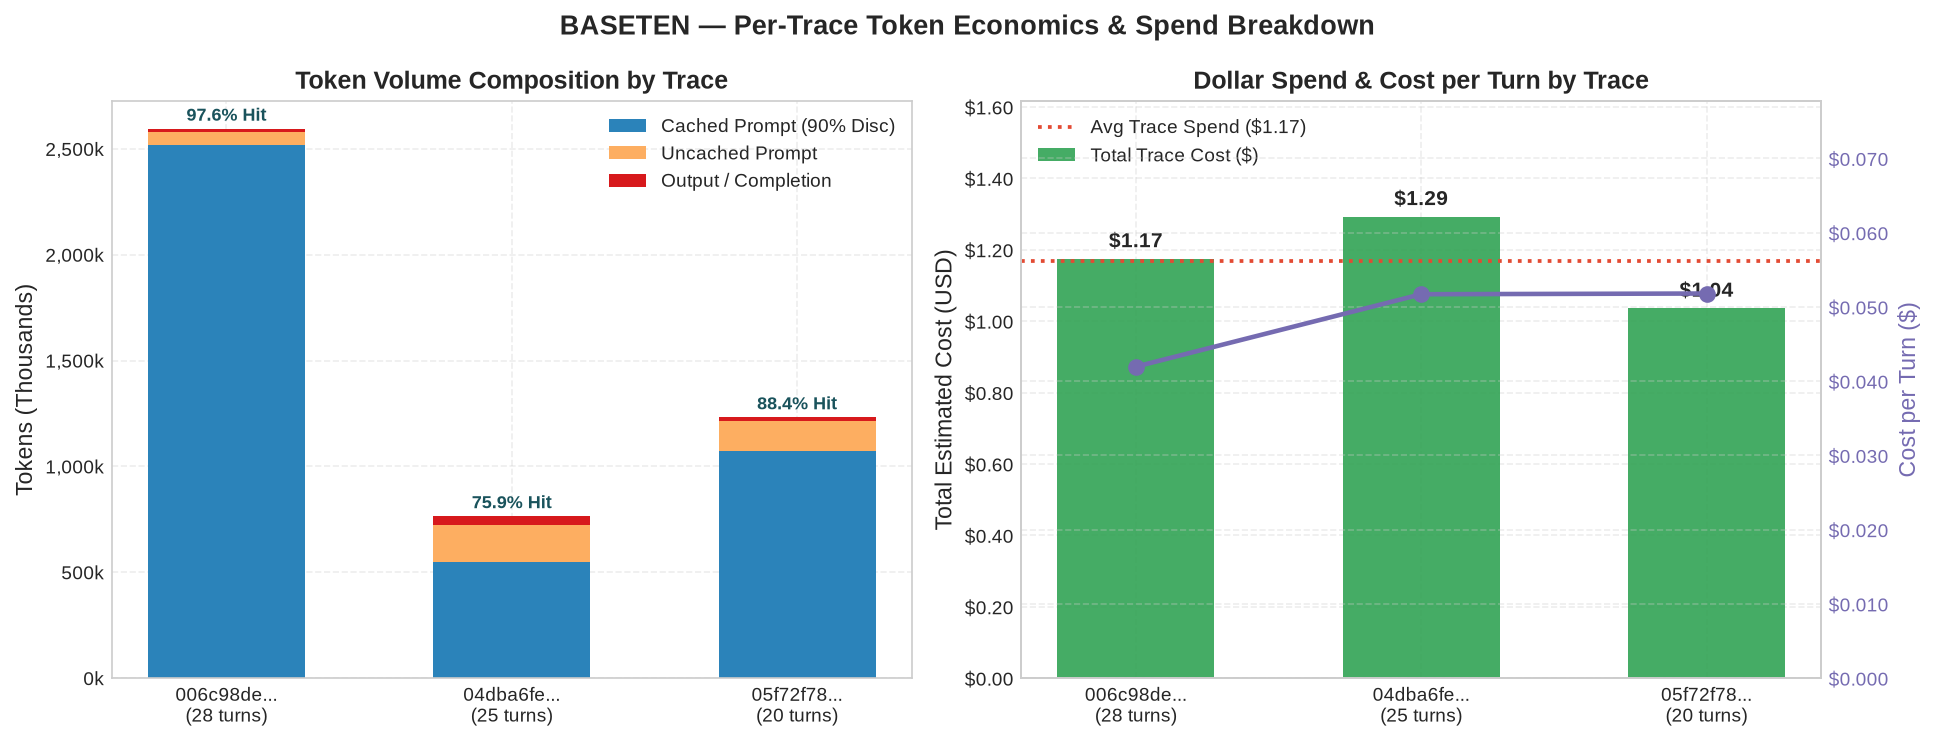

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

x_labels = [f"{t['traceId'][:8]}...\n({t['requestCount']} turns)" for t in df_traces.to_dict('records')]
x = np.arange(len(x_labels))
width = 0.55

# --- Panel A: Token Composition Stacked Bar ---
cached_k = df_traces['cachedInputTokens'] / 1e3
uncached_k = df_traces['uncachedInputTokens'] / 1e3
output_k = df_traces['outputTokens'] / 1e3

p1 = ax1.bar(x, cached_k, width, label='Cached Prompt (90% Disc)', color='#2b83ba')
p2 = ax1.bar(x, uncached_k, width, bottom=cached_k, label='Uncached Prompt', color='#fdae61')
p3 = ax1.bar(x, output_k, width, bottom=cached_k + uncached_k, label='Output / Completion', color='#d7191c')

for i, row in df_traces.iterrows():
    total_k = row['totalTokens'] / 1e3
    hit_pct = row['cacheHitRate'] * 100
    ax1.text(i, total_k + 20, f"{hit_pct:.1f}% Hit", ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#1a535c')

ax1.set_title("Token Volume Composition by Trace", fontweight='bold')
ax1.set_ylabel("Tokens (Thousands)")
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels)
ax1.legend(loc='upper right')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}k"))

# --- Panel B: Dollar Spend Breakdown ---
costs = df_traces['estimatedCostUsd']
cost_per_req = df_traces['costPerRequestUsd']

bars = ax2.bar(x, costs, width, color='#31a354', alpha=0.9, label='Total Trace Cost ($)')
for bar, c in zip(bars, costs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"${c:.2f}", ha='center', va='bottom', fontweight='bold')

# Overlay Cost per Request on twin axis
ax2_twin = ax2.twinx()
ax2_twin.plot(x, cost_per_req, color='#756bb1', marker='o', linewidth=2.2, markersize=7, label='Cost / Turn ($)')
ax2_twin.set_ylabel("Cost per Turn ($)", color='#756bb1')
ax2_twin.tick_params(axis='y', labelcolor='#756bb1')
ax2_twin.yaxis.set_major_formatter(ticker.FormatStrFormatter("$%.3f"))
ax2_twin.set_ylim(0, max(cost_per_req) * 1.5)

# Average cost line
avg_cost_val = trace_breakdown.get("avgCostPerTraceUsd", 0.0)
ax2.axhline(avg_cost_val, color='#e34a33', linestyle=':', linewidth=1.8, label=f'Avg Trace Spend (${avg_cost_val:.2f})')

ax2.set_title("Dollar Spend & Cost per Turn by Trace", fontweight='bold')
ax2.set_ylabel("Total Estimated Cost (USD)")
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter("$%.2f"))
ax2.set_ylim(0, max(costs) * 1.25)
ax2.legend(loc='upper left')

plt.suptitle(f"{SELECTED_PROVIDER.upper()} — Per-Trace Token Economics & Spend Breakdown", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. KV Cache Hit Rate Dynamics Across Conversation Turns

Agentic workflows build long-context conversations as tools return observations. We track how context length grows over turns and how KV cache reuse behaves.

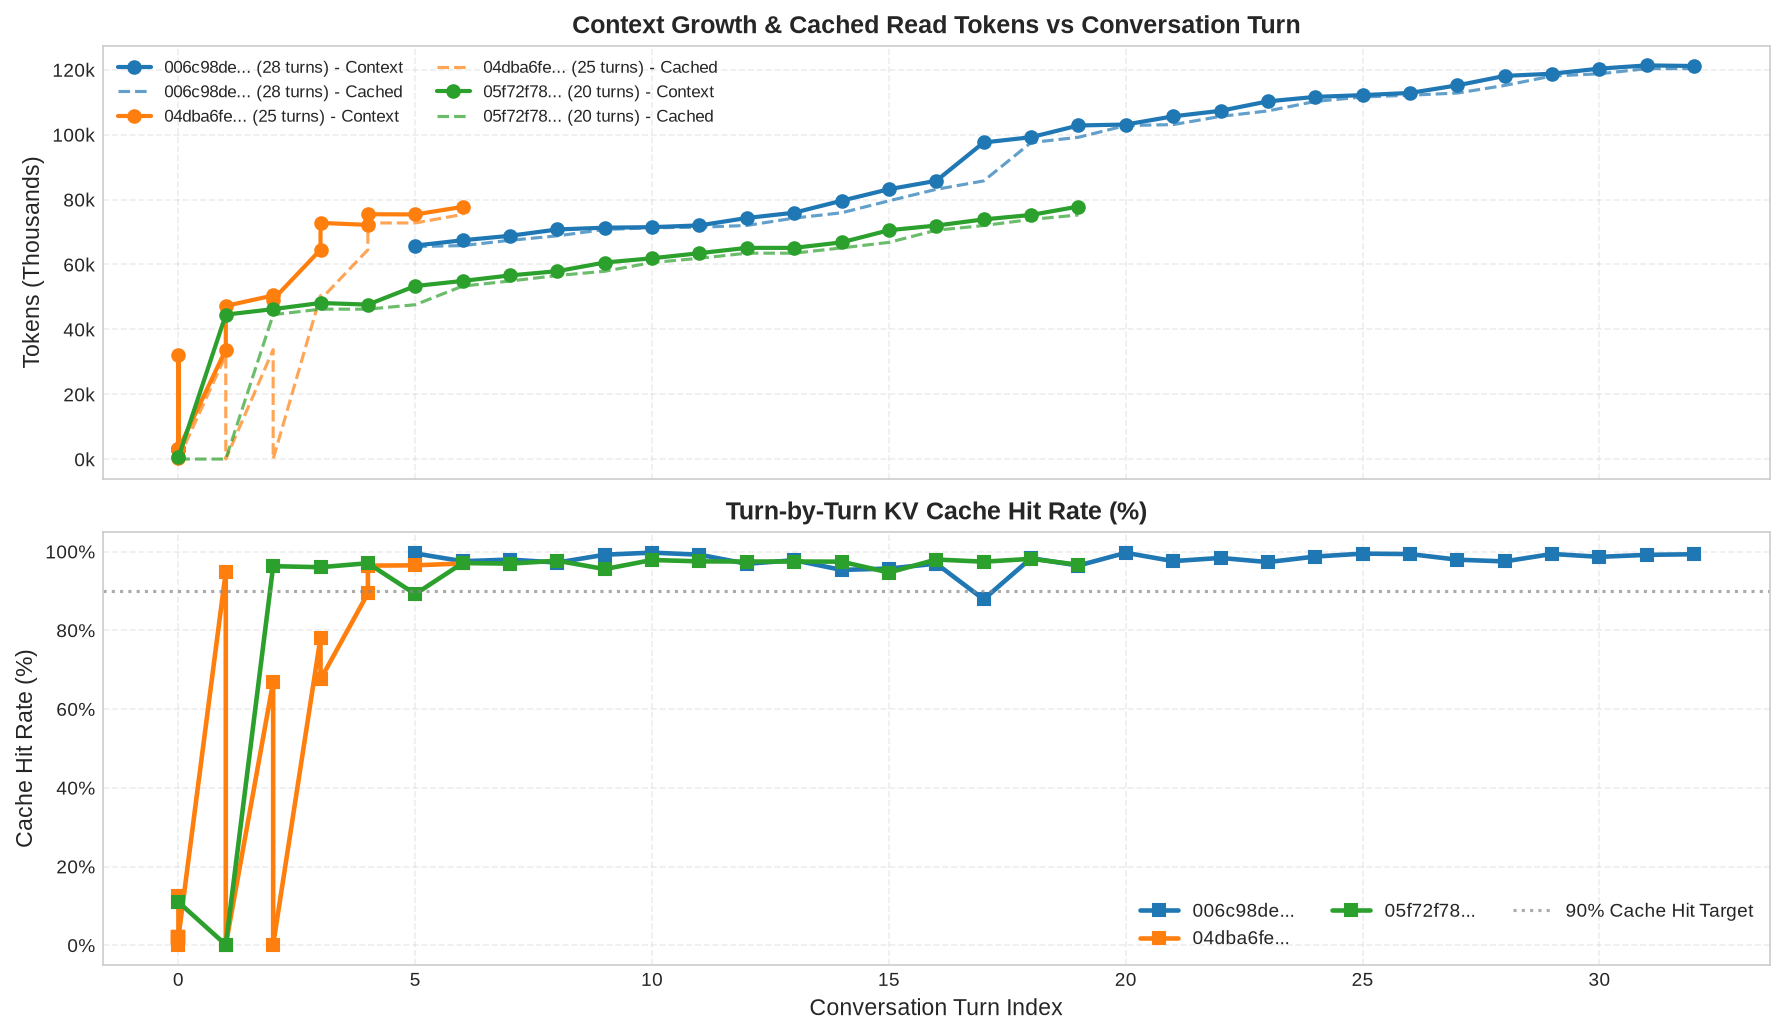

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, dpi=150)

unique_traces = df_turns['source_trace_id'].unique()
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Top: Context Length and Cached Tokens vs Turns
for idx, trace_id in enumerate(unique_traces):
    sub = df_turns[df_turns['source_trace_id'] == trace_id].sort_values('turn_index')
    color = palette[idx % len(palette)]
    label = f"{trace_id[:8]}... ({len(sub)} turns)"
    ax1.plot(sub['turn_index'], sub['input_tokens'] / 1e3, marker='o', linewidth=2, color=color, label=f"{label} - Context")
    ax1.plot(sub['turn_index'], sub['cached_tokens'] / 1e3, linestyle='--', linewidth=1.5, color=color, alpha=0.7, label=f"{label} - Cached")

ax1.set_title("Context Growth & Cached Read Tokens vs Conversation Turn", fontweight='bold')
ax1.set_ylabel("Tokens (Thousands)")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}k"))
ax1.legend(loc='upper left', ncol=2, fontsize=8)

# Bottom: Cache Hit Rate %
for idx, trace_id in enumerate(unique_traces):
    sub = df_turns[df_turns['source_trace_id'] == trace_id].sort_values('turn_index')
    color = palette[idx % len(palette)]
    label = f"{trace_id[:8]}..."
    ax2.plot(sub['turn_index'], sub['cache_hit_rate'] * 100, marker='s', linewidth=2.2, color=color, label=label)

ax2.axhline(90, color='#888888', linestyle=':', alpha=0.7, label='90% Cache Hit Target')
ax2.set_title("Turn-by-Turn KV Cache Hit Rate (%)", fontweight='bold')
ax2.set_xlabel("Conversation Turn Index")
ax2.set_ylabel("Cache Hit Rate (%)")
ax2.set_ylim(-5, 105)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter())
ax2.legend(loc='lower right', ncol=3)

plt.tight_layout()
plt.show()


## 6. Time to First Token (TTFT) vs Input Sequence Length

Evaluating whether KV cache reuse prevents prefill bottlenecks as prompt length scales past 100k tokens.

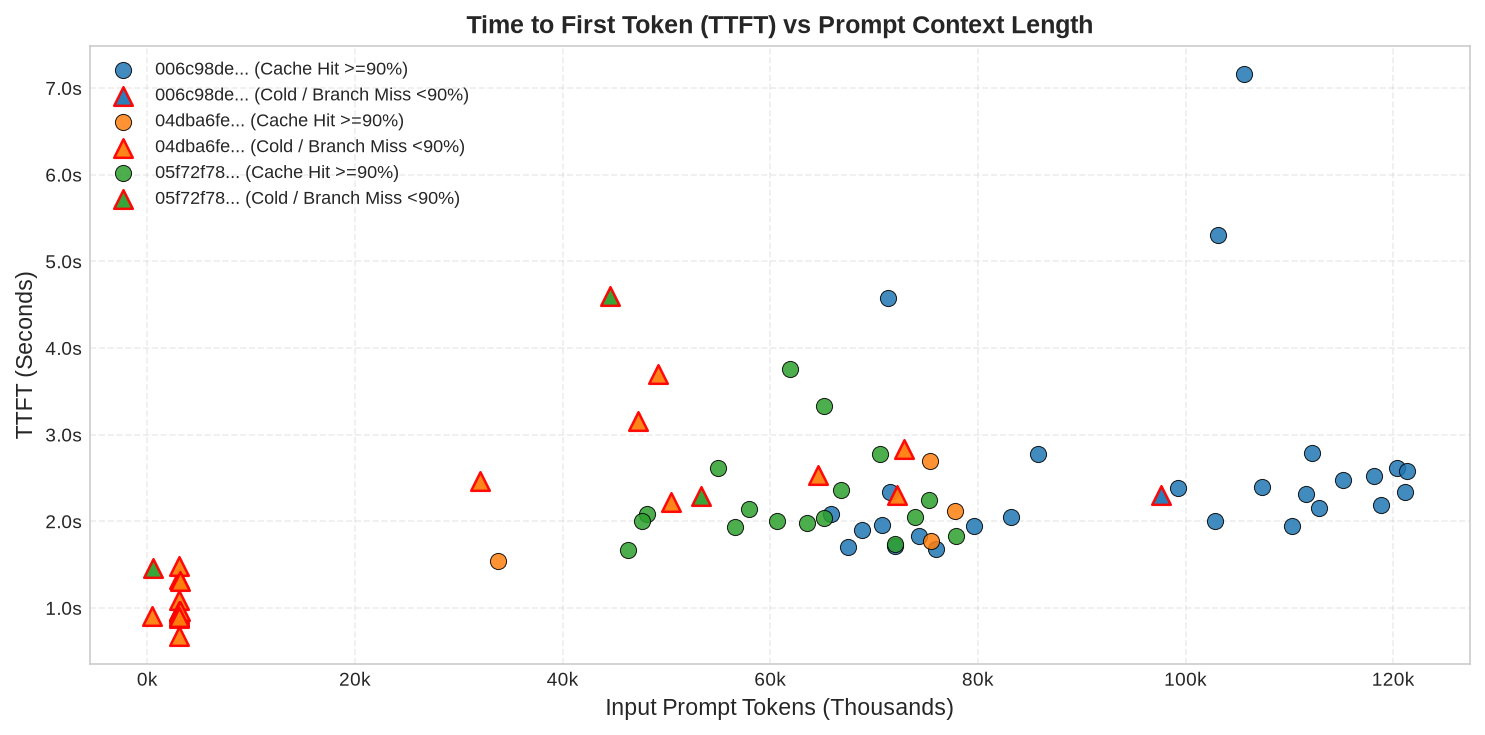

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

for idx, trace_id in enumerate(unique_traces):
    sub = df_turns[df_turns['source_trace_id'] == trace_id]
    color = palette[idx % len(palette)]
    
    # Split by cache hit rate threshold (90%)
    hit_mask = sub['cache_hit_rate'] >= 0.90
    
    ax.scatter(
        sub.loc[hit_mask, 'input_tokens'] / 1e3,
        sub.loc[hit_mask, 'ttft_ms'] / 1e3,
        color=color,
        s=60,
        alpha=0.85,
        label=f"{trace_id[:8]}... (Cache Hit >=90%)",
        edgecolor='black',
        linewidth=0.5
    )
    
    if (~hit_mask).any():
        ax.scatter(
            sub.loc[~hit_mask, 'input_tokens'] / 1e3,
            sub.loc[~hit_mask, 'ttft_ms'] / 1e3,
            color=color,
            s=80,
            marker='^',
            alpha=0.95,
            label=f"{trace_id[:8]}... (Cold / Branch Miss <90%)",
            edgecolor='red',
            linewidth=1.2
        )

ax.set_title("Time to First Token (TTFT) vs Prompt Context Length", fontweight='bold')
ax.set_xlabel("Input Prompt Tokens (Thousands)")
ax.set_ylabel("TTFT (Seconds)")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}k"))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1fs"))
ax.legend(loc='upper left', fontsize=8.5)

plt.tight_layout()
plt.show()


## 7. Latency Decomposition: Waiting / TTFT vs Decode Duration per Turn

Decomposing turn-by-turn request latency into prefill/waiting time and active token generation duration.

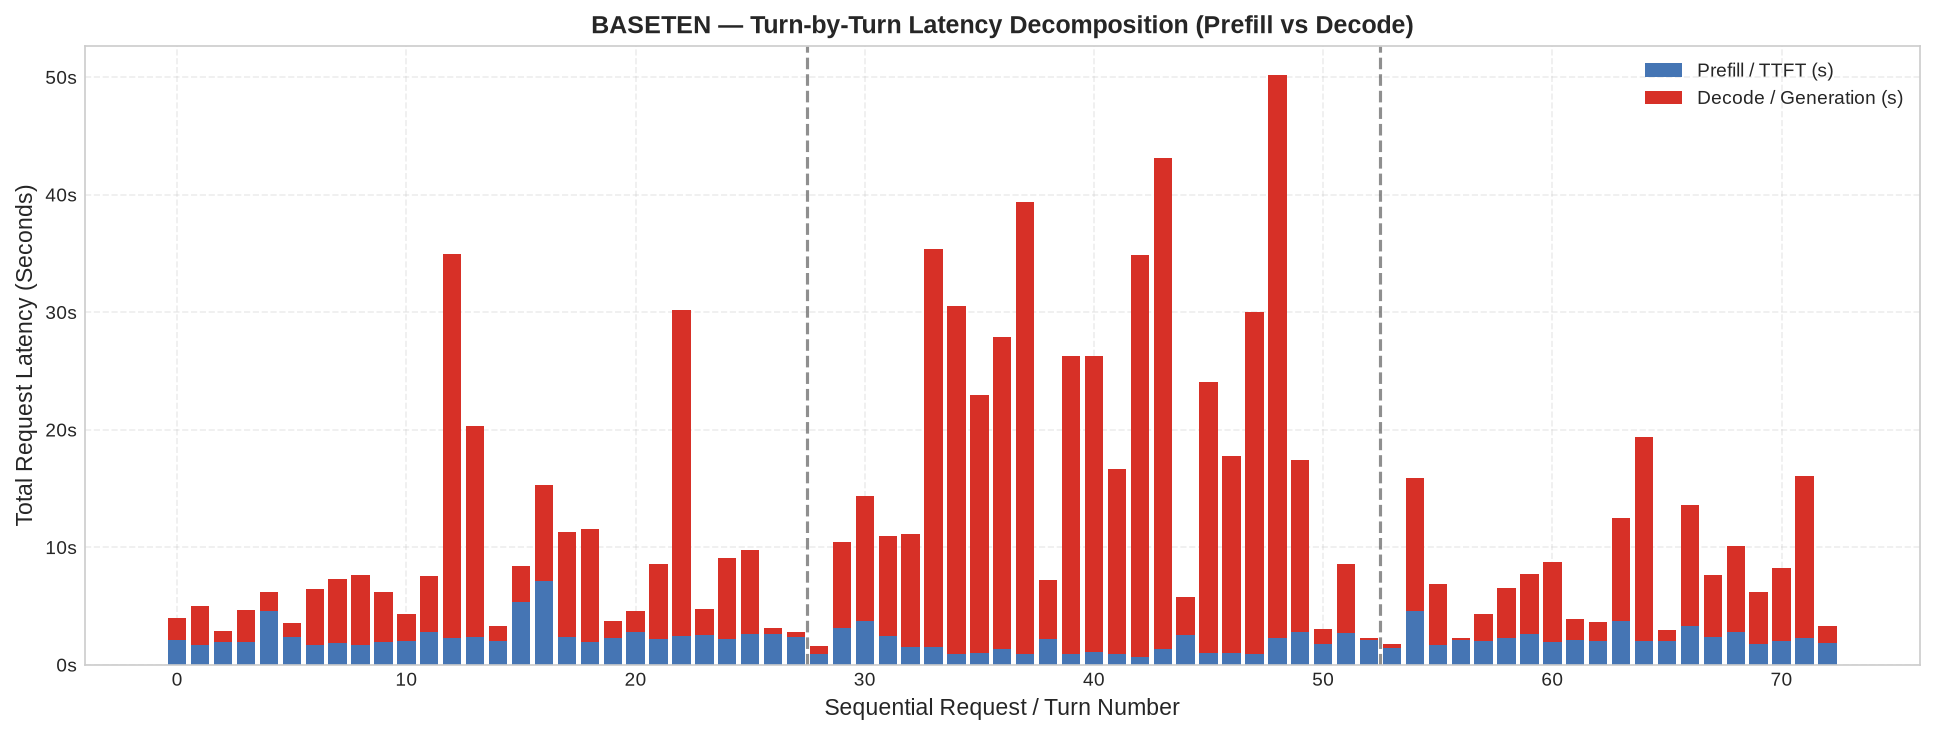

In [7]:
fig, ax = plt.subplots(figsize=(13, 5), dpi=150)

sessions = df_turns['session_num']
ttft_s = df_turns['ttft_ms'] / 1e3
decode_s = df_turns['decode_duration_ms'] / 1e3

ax.bar(sessions, ttft_s, label='Prefill / TTFT (s)', color='#4575b4', width=0.8)
ax.bar(sessions, decode_s, bottom=ttft_s, label='Decode / Generation (s)', color='#d73027', width=0.8)

# Trace boundaries
boundary_indices = df_turns.groupby('source_trace_id')['session_num'].min().values[1:]
for b in boundary_indices:
    ax.axvline(b - 0.5, color='#444444', linestyle='--', alpha=0.6)

ax.set_title(f"{SELECTED_PROVIDER.upper()} — Turn-by-Turn Latency Decomposition (Prefill vs Decode)", fontweight='bold')
ax.set_xlabel("Sequential Request / Turn Number")
ax.set_ylabel("Total Request Latency (Seconds)")
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0fs"))

plt.tight_layout()
plt.show()


## 8. Inter-Token Latency (ITL) & Throughput Distribution

Analysis of streaming token delivery pacing and output throughput across all completed turns.

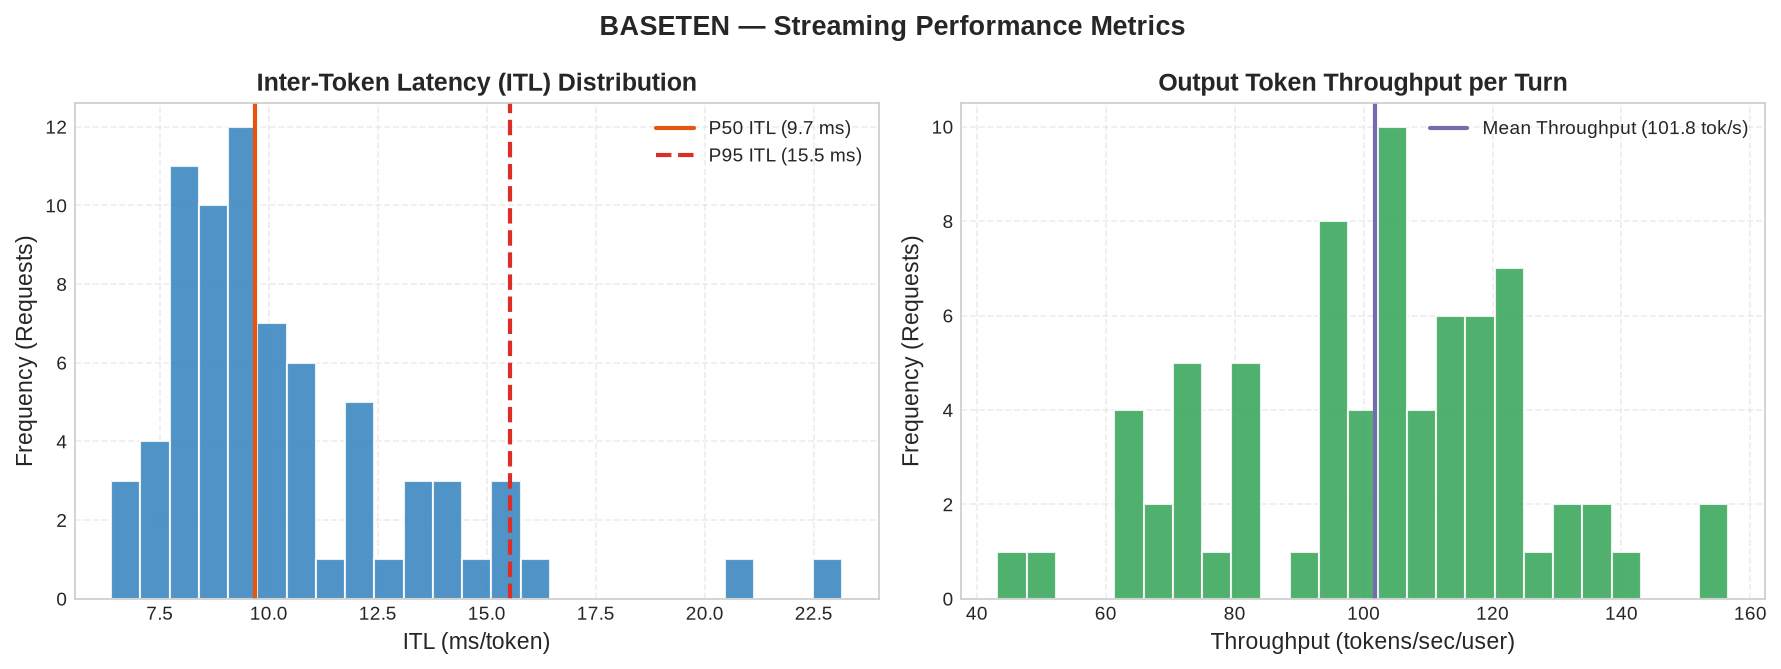

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)

valid_itl = df_turns[df_turns['itl_ms'] > 0]['itl_ms']
valid_tps = df_turns[df_turns['decode_throughput'] > 0]['decode_throughput']

# Left: ITL Distribution
ax1.hist(valid_itl, bins=25, color='#3182bd', edgecolor='white', alpha=0.85)
p50_itl = valid_itl.median()
p95_itl = valid_itl.quantile(0.95)
ax1.axvline(p50_itl, color='#e6550d', linestyle='-', linewidth=2, label=f'P50 ITL ({p50_itl:.1f} ms)')
ax1.axvline(p95_itl, color='#de2d26', linestyle='--', linewidth=2, label=f'P95 ITL ({p95_itl:.1f} ms)')
ax1.set_title("Inter-Token Latency (ITL) Distribution", fontweight='bold')
ax1.set_xlabel("ITL (ms/token)")
ax1.set_ylabel("Frequency (Requests)")
ax1.legend(loc='upper right')

# Right: Output Token Throughput per User
ax2.hist(valid_tps, bins=25, color='#31a354', edgecolor='white', alpha=0.85)
mean_tps = valid_tps.mean()
ax2.axvline(mean_tps, color='#756bb1', linestyle='-', linewidth=2, label=f'Mean Throughput ({mean_tps:.1f} tok/s)')
ax2.set_title("Output Token Throughput per Turn", fontweight='bold')
ax2.set_xlabel("Throughput (tokens/sec/user)")
ax2.set_ylabel("Frequency (Requests)")
ax2.legend(loc='upper right')

plt.suptitle(f"{SELECTED_PROVIDER.upper()} — Streaming Performance Metrics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Multi-Provider Comparative Benchmark (Baseten vs Fireworks vs Together)

Cross-provider evaluation across all completed Moonshot Kimi-K3 AgentX runs in `kimi-k3-agentx-20260904T121154Z-070ffb74`.

,Provider,Completed Turns,Completed Traces,KV Hit Rate (%),Avg TTFT (ms),Avg ITL (ms),Decode Speed (tok/s),Total Spend ($),Cost / Trace ($)
0,Baseten,73,3,91.624602,2200.775624,10.470348,101.756622,3.503625,1.167875
1,Fireworks,51,2,91.810108,3010.611213,19.589314,52.163069,2.000050,1.000025
2,Together,63,3,91.592292,1981.287721,14.479414,83.708044,3.007233,1.002411


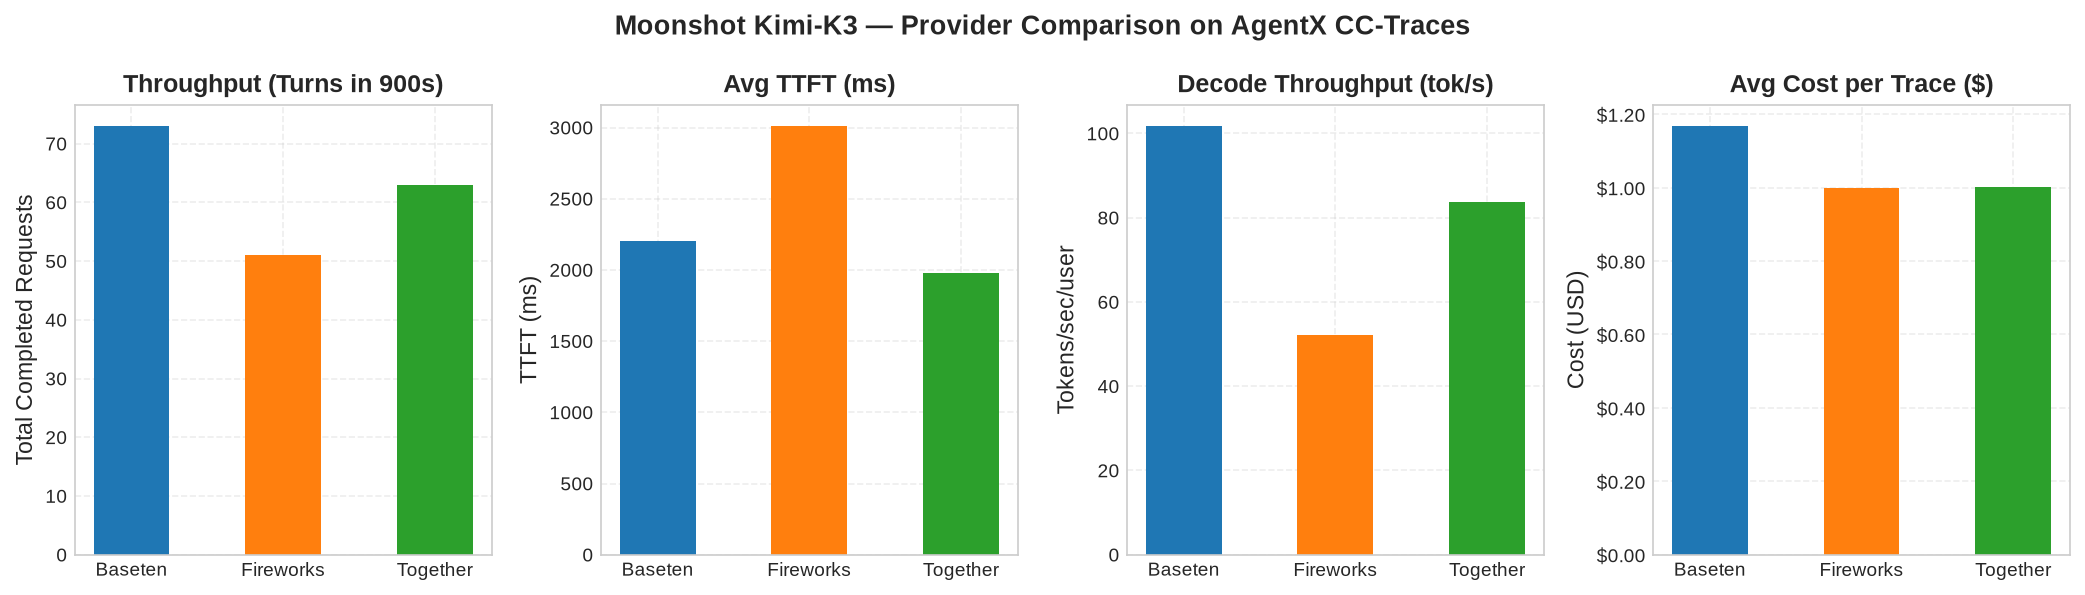

In [9]:
# Ingest all provider runs
comparison_rows = []

for provider_name, art_dir in PROVIDER_ARTIFACTS.items():
    aiperf_p = art_dir / "profile_export_aiperf.json"
    cost_p = art_dir / "trace-cost-breakdown.json"
    
    if not (aiperf_p.exists() and cost_p.exists()):
        continue
        
    p_summary = load_json(aiperf_p)
    p_cost = load_json(cost_p)
    
    ttft_avg = p_summary.get("time_to_first_token", {}).get("avg", 0.0)
    itl_avg = p_summary.get("inter_token_latency", {}).get("avg", 0.0)
    tps_avg = p_summary.get("output_token_throughput_per_user", {}).get("avg", 0.0)
    total_reqs = p_cost.get("totalRequests", 0)
    total_traces = p_cost.get("totalTraces", 0)
    total_spend = p_cost.get("totalEstimatedCostUsd", 0.0)
    avg_trace_spend = p_cost.get("avgCostPerTraceUsd", 0.0)
    
    tot_inp = sum(t["inputTokens"] for t in p_cost.get("traces", []))
    tot_cached = sum(t["cachedInputTokens"] for t in p_cost.get("traces", []))
    hit_rate = (tot_cached / tot_inp * 100) if tot_inp > 0 else 0.0
    
    comparison_rows.append({
        "Provider": provider_name.capitalize(),
        "Completed Turns": total_reqs,
        "Completed Traces": total_traces,
        "KV Hit Rate (%)": hit_rate,
        "Avg TTFT (ms)": ttft_avg,
        "Avg ITL (ms)": itl_avg,
        "Decode Speed (tok/s)": tps_avg,
        "Total Spend ($)": total_spend,
        "Cost / Trace ($)": avg_trace_spend,
    })

df_comp = pd.DataFrame(comparison_rows)
display(df_comp)

# Comparative Bar Plots
fig, axes = plt.subplots(1, 4, figsize=(14, 4), dpi=150)
provs = df_comp['Provider']

# 1. Completed Turns in 900s
axes[0].bar(provs, df_comp['Completed Turns'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], width=0.5)
axes[0].set_title("Throughput (Turns in 900s)", fontweight='bold')
axes[0].set_ylabel("Total Completed Requests")

# 2. Avg TTFT
axes[1].bar(provs, df_comp['Avg TTFT (ms)'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], width=0.5)
axes[1].set_title("Avg TTFT (ms)", fontweight='bold')
axes[1].set_ylabel("TTFT (ms)")

# 3. Decode Speed
axes[2].bar(provs, df_comp['Decode Speed (tok/s)'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], width=0.5)
axes[2].set_title("Decode Throughput (tok/s)", fontweight='bold')
axes[2].set_ylabel("Tokens/sec/user")

# 4. Cost per Trace
axes[3].bar(provs, df_comp['Cost / Trace ($)'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], width=0.5)
axes[3].set_title("Avg Cost per Trace ($)", fontweight='bold')
axes[3].set_ylabel("Cost (USD)")
axes[3].yaxis.set_major_formatter(ticker.FormatStrFormatter("$%.2f"))

plt.suptitle("Moonshot Kimi-K3 — Provider Comparison on AgentX CC-Traces", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
